In [15]:
from models.old_depth_focal import PP3DR
import torch
from datasets.nrgbd_dataset import nrgbd_dataset
import matplotlib.pyplot as plt

In [17]:
model = PP3DR()
remove_front = True

loaded_state_dict = torch.load("/vulcanscratch/hughma/PP3DR/gradient-matching/PP3DR.pth", weights_only=True)
if remove_front:
    # The lines here are necessary if all the loaded state dict entries begin with an extra "module."
    new_state_dict = {}
    for key in loaded_state_dict:
        new_state_dict[key[7:]] = loaded_state_dict[key]
    model.load_state_dict(new_state_dict)
else:
    model.load_state_dict(loaded_state_dict)
print("post load")

model = model.eval().to("cuda")
dataset = nrgbd_dataset()
data = dataset[0]
print("post dataset")
for key in data:
    data[key] = data[key].unsqueeze(0)
with torch.amp.autocast("cuda", dtype = torch.bfloat16), torch.no_grad():
    pred = model(data['images'].to("cuda"), data['rope_x'].to("cuda"), data['rope_y'].to("cuda"))
print("post pred")
for key in pred:
    pred[key] = pred[key].to(torch.float32).cpu().numpy(force=True)
    print(f"{key}: {pred[key].shape}")
print("done")

post load


Precomputing NRGBD image file paths: 9it [00:00, 97.50it/s]


post dataset
post pred
log_depths: (1, 10, 512, 512)
fx: (1, 10)
fy: (1, 10)
cx: (1, 10)
cy: (1, 10)
relative_camera_translations: (1, 9, 3)
relative_camera_rotations: (1, 9, 3, 3)
done


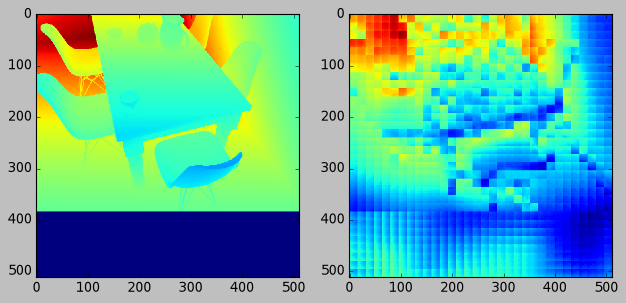

In [18]:
# plt.style.use("seaborn-v0_8-darkgrid")
plt.style.use("classic")
fig, (a1, a2) = plt.subplots(1, 2)
a1.imshow(data['depths'][0][0])
a2.imshow(pred['log_depths'][0][0])
fig.tight_layout()